# 05 — LoRA fine-tuned transcript scorer: the content-aware arm

> **Status: executed against a completed five-fold run** (`whisper_Qwen2.5-1.5B-Instruct-4bit`,
> 876 responses / 438 speakers), plus the gold-transcript ablation (589 responses)
> and two untrained baselines (§4).
> Findings are written from measured numbers; every figure below is reproducible from the
> caches in `data/derived/`.

Notebooks 01–04 built four scoring arms and every one of them is **content-blind**:
fluency timing, prosody, word counts, lexical diversity. None reads what the candidate
actually *said*. `reports/evaluation_report.md` closes on that limitation —
Recommendation 3 — because it makes the report's most interesting result conditional:
ASR error did not independently propagate into scoring error (partial r ≈ −0.01), but a
scorer that never looks at words is close to the *least* sensitive thing you could
measure that on. Transcription errors have to reach the score through a feature, and a
word-count feature barely notices which words were wrong.

This notebook adds the fifth arm: a small instruct model LoRA-fine-tuned on the
transcripts, decoded ordinally, evaluated under the **identical protocol** — same 876
P3+P4 dev responses, same speaker-grouped `GroupKFold(5)`, same `speechlab.evaluation`.
Training happens out-of-notebook in `scripts/finetune_lora.py` (hours, resumable); this
notebook reads its out-of-fold cache and does the analysis.

Three things are being measured, and the headline number is the least interesting of
them:

1. **Does reading content buy accuracy?** The bar is Random Forest **QWK 0.558**; the
   honesty floor is word-count Ridge **QWK 0.500**.
2. **Did the fine-tuning do anything?** Added after the fact, and it should not have
   been: §4 scores the same model with the adapter removed. Without that floor, "the
   content-aware arm is worse" compares this arm to a *different pipeline* and says
   nothing about whether training helped.
3. **Does the ordinal decode make scale compression worse?** `expected_score` averages
   over the band distribution, and averaging shrinks towards the centre — the same
   mechanism behind the compression already documented in notebook 04 (band 2 over-scored
   **+0.96**, band 5 under-scored **−0.70**). A decode that improves QWK while flattening
   the ends further would be a bad trade for an assessment scorer, and it would not show
   up in a headline metric.

Design amendment for the premise this arm breaks: `docs/design.md`, 2026-08-27.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf

from speechlab.data import load_responses
from speechlab.acoustic_features import fluency_features, FLUENCY_FEATURES, PROSODY_FEATURES
from speechlab.text_features import mtld, normalise_tokens
from speechlab.evaluation import evaluate, to_grid
from speechlab.ordinal import BandCodec, band_probabilities, expected_score, argmax_score

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data" / "sandi-corpus-2025").exists(), f"corpus not found under {ROOT}"

CORPUS = ROOT / "data" / "sandi-corpus-2025"
DERIVED = ROOT / "data" / "derived"
PARTS = ["P3", "P4"]          # long single turns: one response, one score
SEED = 42

# which finetune_lora.py run to analyse: <transcripts>_<model slug>
TAG = "whisper_Qwen2.5-1.5B-Instruct-4bit"
OOF = DERIVED / f"lora_oof_{TAG}.json"

print(f"project root: {ROOT.name}/  |  parts: {PARTS}  |  tag: {TAG}")

project root: cefr-speech-scoring-lab/  |  parts: ['P3', 'P4']  |  tag: whisper_Qwen2.5-1.5B-Instruct-4bit


## 1. The band grid, and the prior it carries

`BandCodec` maps the 0.5-step score grid onto single-character class labels, so one
forward pass produces a distribution over every band at a single token position. The
grid bounds come from the observed human scores, and snapping is delegated to
`evaluation.to_grid` — the same function that builds the QWK confusion matrix, so a
training label and a gold class cannot disagree about which band a score is in.

The band histogram below is not decoration. It is **unimodal at 4.0 with thin tails**,
and the tails are exactly where notebook 04 found the compression. An expectation decode
is a weighted average, so any probability mass the model leaves on the crowded middle
pulls a tail prediction inwards. Whatever this arm scores, it starts from a prior that
punishes the ends — that is the context for section 4, and it is stated here rather than
discovered later.

In [2]:
scored = pd.concat([load_responses(CORPUS, p).assign(part=p) for p in PARTS], ignore_index=True)
codec = BandCodec.from_scores(scored.score)

hist = (scored.score.value_counts().sort_index()
        .rename_axis("score").rename("n").to_frame())
hist["label"] = codec.encode(hist.index.to_numpy())
hist["share"] = (hist.n / len(scored) * 100).round(1)

print(f"{len(scored)} responses / {scored.speaker.nunique()} speakers")
print(f"{len(codec)} bands: {codec.labels[0]}–{codec.labels[-1]}  ({codec.lo}–{codec.hi})")
hist

876 responses / 438 speakers
8 bands: A–H  (2.0–5.5)


,n,label,share
score,,,
2.0,11,A,1.3
2.5,31,B,3.5
3.0,116,C,13.2
3.5,174,D,19.9
4.0,248,E,28.3
4.5,164,F,18.7
5.0,110,G,12.6
5.5,22,H,2.5


## 2. Out-of-fold predictions from the LoRA arm

`scripts/finetune_lora.py` trains one adapter per fold and predicts that fold's held-out
speakers, so every prediction below comes from a model that never saw the speaker it is
scoring — including that speaker's *other* test part, which is the leakage notebook 03
measured and closed.

The cache stores the full band distribution per response, not just the two decodes. That
is deliberate: the decode is a post-hoc choice, so section 5 can re-decode at a different
temperature without retraining anything.

In [3]:
assert OOF.exists(), (
    f"no cache at {OOF.name} — run:\n"
    f"  python scripts/download_dev_audio.py\n"
    f"  python scripts/transcribe_dev.py --parts P3 P4\n"
    f"  python scripts/finetune_lora.py"
)
cache = json.loads(OOF.read_text())
run = cache["meta"]
print({k: run[k] for k in ("model", "transcripts", "iters", "rank", "num_layers",
                           "learning_rate", "n_splits", "n_responses")})

lora = pd.concat([pd.DataFrame({
    "utt": f["utt"], "speaker": f["speaker"], "part": f["part"],
    "score": f["y_true"], "lora_expected": f["expected"], "lora_argmax": f["argmax"],
    "fold": int(k), "probs": [np.array(p) for p in f["probs"]],
}) for k, f in sorted(cache["folds"].items(), key=lambda kv: int(kv[0]))], ignore_index=True)

assert len(cache["folds"]) == run["n_splits"], "incomplete run — some folds are missing"
assert lora.utt.is_unique, "an utterance appears in more than one fold"
print(f"{len(lora)} out-of-fold predictions across {lora.fold.nunique()} folds")
lora.groupby("fold").agg(n=("utt", "size"), speakers=("speaker", "nunique")).T

{'model': 'mlx-community/Qwen2.5-1.5B-Instruct-4bit', 'transcripts': 'whisper', 'iters': 400, 'rank': 8, 'num_layers': 8, 'learning_rate': 0.0001, 'n_splits': 5, 'n_responses': 876}
876 out-of-fold predictions across 5 folds


fold,0,1,2,3,4
n,176,176,176,174,174
speakers,88,88,88,87,87


## 3. Against the notebook-03 arms, on identical folds

A comparison between two cross-validated scorers is only clean if they were validated on
the *same partition*. Notebook 03 showed how much fold assignment can move a number
(±0.04 QWK at n=100, and the whole grouped-vs-naive leakage exhibit), so rather than
re-running `GroupKFold` here and hoping it lands the same way, the fold index is read
**out of the LoRA cache** and handed to `cross_val_predict` as an explicit split. Every
arm in the table below is therefore scored on exactly the same held-out rows.

Rows are restricted to those the LoRA arm predicted. With Whisper transcripts that is all
876; with a gold-transcript run it is the ~68% the corpus annotates, and the baseline is
re-fitted on that subset rather than quoted from the report — a QWK measured on 600 rows
is not comparable to one measured on 876.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# the notebook-03 feature matrix, rebuilt from the same caches
frames = []
for part in PARTS:
    df = load_responses(CORPUS, part)
    trans = json.load(open(DERIVED / f"transcripts_{part}_small.json"))
    pros = json.load(open(DERIVED / f"prosody_{part}_full.json"))
    rows = []
    for r in df.itertuples():
        words = trans[r.utt]
        duration = sf.info(str(CORPUS / r.flac)).duration
        rows.append({"utt": r.utt, "speaker": r.speaker, "part": part, "score": r.score,
                     **fluency_features(words, duration),
                     "mtld": mtld(normalise_tokens([w["w"] for w in words])),
                     **pros[r.utt]})
    frames.append(pd.DataFrame(rows))
feats = pd.concat(frames, ignore_index=True)
feats["part_p4"] = (feats.part == "P4").astype(float)

data = feats.merge(lora[["utt", "lora_expected", "lora_argmax", "fold", "probs"]], on="utt")
print(f"matched rows: {len(data)} of {len(lora)} LoRA predictions, {len(feats)} feature rows")

F_MTLD = [f if f != "ttr" else "mtld" for f in FLUENCY_FEATURES]
FEATURES = F_MTLD + PROSODY_FEATURES + ["part_p4"]
y = data.score.to_numpy()

# the LoRA arm's own folds, reused verbatim
folds = data.fold.to_numpy()
cv = [(np.where(folds != k)[0], np.where(folds == k)[0]) for k in sorted(set(folds))]

preds = {
    "mean predictor": np.full_like(y, y.mean()),
    "LoRA (expected)": data.lora_expected.to_numpy(),
    "LoRA (argmax)": data.lora_argmax.to_numpy(),
}
for name, cols in [("word-count Ridge", ["n_words", "part_p4"]), ("Ridge", FEATURES)]:
    preds[name] = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
                                    data[cols].to_numpy(), y, cv=cv)
preds["Random Forest"] = cross_val_predict(
    RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    data[FEATURES].to_numpy(), y, cv=cv)

results = pd.DataFrame({n: evaluate(y, p) for n, p in preds.items()}).T
results["pred_range"] = [round(np.ptp(p), 2) for p in preds.values()]
results.round(3).sort_values("QWK", ascending=False)

matched rows: 876 of 876 LoRA predictions, 876 feature rows


,pearson_r,spearman_rho,MAE,RMSE,QWK,pred_range
Random Forest,0.622,0.625,0.456,0.575,0.558,2.38
Ridge,0.609,0.610,0.464,0.582,0.548,2.89
word-count Ridge,0.589,0.599,0.474,0.593,0.500,2.93
LoRA (argmax),0.505,0.529,0.511,0.670,0.446,2.00
LoRA (expected),0.550,0.559,0.523,0.647,0.415,1.72
mean predictor,NaN,NaN,0.580,0.733,0.000,0.00


## 4. The floor this arm never had: zero-shot

Section 3 compares the fine-tuned scorer against *other systems*, which cannot answer the
question a reader actually asks on seeing QWK 0.446 next to 0.558 — did the fine-tuning
help? The arm has been measured only against a Random Forest, so "worse" so far means
worse than a different pipeline, not worse than where it started. Its own baseline is the
same model with the adapter removed: `LoRABandScorer(adapter_path=None)`, identical prompt,
identical rows, no training at all.

Nothing is fitted, so every row is held out by construction and no cross-validation is
required — but the run reuses the same `GroupKFold` loop so the fold index means the same
thing here as everywhere else in this notebook, and the cell below asserts that the rows
and folds match the trained arm rather than assuming it.

Two prompts, because one of them is a confound. `build_prompt` deliberately labels the
bands `A`–`H` with no CEFR names attached: blank letters are the right choice for
fine-tuning, which would otherwise have to overwrite whatever the pretrained model already
believes about "B2". For an *untrained* model that same choice is a handicap — it is being
asked to use a scale nobody has given it the key to, so a low score would be ambiguous
between "the model cannot judge proficiency" and "the model cannot guess what H means".
The second run (`--rubric`) names the anchors from `data_gates.md` gate 1
(1=A1 … 5=C1), which separates the two explanations.

In [5]:
ZERO_SHOT = {
    "zero-shot, blank labels": "zeroshot_Qwen2.5-1.5B-Instruct-4bit",
    "zero-shot, CEFR-anchored": "zeroshot-rubric_Qwen2.5-1.5B-Instruct-4bit",
}

zs = {}
for name, tag in ZERO_SHOT.items():
    path = DERIVED / f"lora_oof_{tag}.json"
    assert path.exists(), (
        f"no cache at {path.name} — run:\n"
        f"  python scripts/finetune_lora.py --zero-shot"
        + (" --rubric" if "rubric" in tag else ""))
    folds_ = json.loads(path.read_text())["folds"]
    frame = pd.concat([pd.DataFrame({
        "utt": f["utt"], "score": f["y_true"], "fold": int(k),
        "expected": f["expected"], "argmax": f["argmax"],
        "probs": [np.array(p) for p in f["probs"]],
    }) for k, f in sorted(folds_.items(), key=lambda kv: int(kv[0]))], ignore_index=True)

    # the untrained arm is only a floor if it is the floor for *these* rows and folds
    chk = frame.merge(lora[["utt", "fold", "score"]], on="utt", suffixes=("", "_ft"))
    assert len(chk) == len(lora), "zero-shot run covers different rows than the trained arm"
    assert (chk.fold == chk.fold_ft).all(), "fold assignment differs from the trained arm"
    assert np.allclose(chk.score, chk.score_ft), "human scores differ from the trained arm"
    zs[name] = frame.set_index("utt").loc[data.utt].reset_index()   # align to `data` order

floor = {f"{n} — {d}": fr[d].to_numpy() for n, fr in zs.items()
         for d in ("expected", "argmax")}
floor["fine-tuned — expected"] = preds["LoRA (expected)"]
floor["fine-tuned — argmax"] = preds["LoRA (argmax)"]

floor_tbl = pd.DataFrame({n: evaluate(y, p) for n, p in floor.items()}).T
floor_tbl["pred_sd"] = [round(float(np.std(p)), 3) for p in floor.values()]
print(f"human score sd: {y.std():.3f}")
floor_tbl.round(3)

human score sd: 0.733


,pearson_r,spearman_rho,MAE,RMSE,QWK,pred_sd
"zero-shot, blank labels — expected",0.228,0.233,0.886,1.076,0.144,0.594
"zero-shot, blank labels — argmax",0.151,0.145,1.525,1.689,0.072,1.003
"zero-shot, CEFR-anchored — expected",0.281,0.292,0.728,0.898,0.122,0.299
"zero-shot, CEFR-anchored — argmax",0.126,0.097,1.137,1.337,0.042,0.422
fine-tuned — expected,0.550,0.559,0.523,0.647,0.415,0.391
fine-tuned — argmax,0.505,0.529,0.511,0.670,0.446,0.487


In [6]:
# QWK is an aggregate over predictions; it cannot show that a decode used two of eight
# bands. The marginal can, and the failure mode it exposes is the reason to print it.
marg = pd.DataFrame({
    "human": pd.Series(to_grid(y, codec.lo, codec.hi) / 2).value_counts(),
    **{n.replace("zero-shot, ", "zs "): pd.Series(fr.argmax.to_numpy()).value_counts()
       for n, fr in zs.items()},
    "fine-tuned": pd.Series(preds["LoRA (argmax)"]).value_counts(),
}).reindex(codec.grid).fillna(0).astype(int)
marg.index = [f"{lab} ({g:.1f})" for lab, g in zip(codec.labels, codec.grid)]
marg.loc["bands used"] = (marg > 0).sum()

gain = floor_tbl.loc["fine-tuned — argmax", "QWK"] - floor_tbl.QWK[:4].max()
print(f"best zero-shot QWK {floor_tbl.QWK[:4].max():.3f} -> fine-tuned "
      f"{floor_tbl.loc['fine-tuned — argmax', 'QWK']:.3f}  (+{gain:.3f})")
marg

best zero-shot QWK 0.144 -> fine-tuned 0.446  (+0.302)


,human,zs blank labels,zs CEFR-anchored,fine-tuned
A (2.0),11,79,3,0
B (2.5),31,0,0,0
C (3.0),116,0,17,174
D (3.5),174,0,0,174
E (4.0),248,0,21,449
F (4.5),164,0,0,52
G (5.0),110,0,674,27
H (5.5),22,797,161,0
bands used,8,2,5,5


## 5. Where the error lives — signed error by band

Mean **signed** error by band shows the direction of failure, which is the thing an
assessment scorer is judged on: over-scoring the weakest candidates and under-scoring the
strongest is not a symmetric inconvenience, it is the failure that makes a scorer unsafe
to use unsupervised.

`pred_range` in the table above is the first warning sign, and this section is the
diagnosis. A perfectly compressed scorer — one that predicts the mean for everybody — has
a *positive* correlation with nothing and a signed-error profile that runs monotonically
from strongly positive at the bottom band to strongly negative at the top. The question
here is whether `expected` buys its continuity by moving in that direction relative to
both `argmax` and the Random Forest.

In [7]:
band = data.score.clip(1, 5.99).astype(int)
arms = ["Random Forest", "LoRA (expected)", "LoRA (argmax)"]

by_band = pd.DataFrame({"n": band.value_counts().sort_index()})
for a in arms:
    err = preds[a] - y
    by_band[f"{a} signed"] = pd.Series(err).groupby(band).mean().round(3)
    by_band[f"{a} MAE"] = pd.Series(np.abs(err)).groupby(band).mean().round(3)
print(by_band)

for a in arms:
    on_grid = np.abs(to_grid(preds[a], y.min(), y.max()) - to_grid(y, y.min(), y.max()))
    print(f"{a:18s} exact {100 * (on_grid == 0).mean():5.1f}%  "
          f"within half a band {100 * (on_grid <= 1).mean():5.1f}%  "
          f"within one band {100 * (on_grid <= 2).mean():5.1f}%")

         n  Random Forest signed  Random Forest MAE  LoRA (expected) signed  \
score                                                                         
2       42                 0.964              0.964                   1.028   
3      290                 0.361              0.455                   0.222   
4      412                -0.120              0.327                  -0.375   
5      132                -0.701              0.701                  -1.012   

       LoRA (expected) MAE  LoRA (argmax) signed  LoRA (argmax) MAE  
score                                                                
2                    1.028                 0.917              0.917  
3                    0.346                 0.216              0.398  
4                    0.440                -0.325              0.400  
5                    1.012                -0.973              0.973  
Random Forest      exact  34.0%  within half a band  81.5%  within one band  97.7%
LoRA (expected)    exa

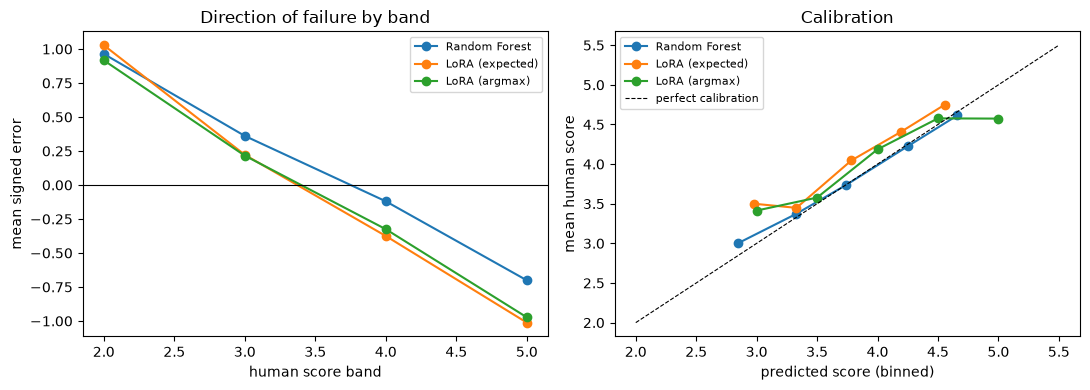

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for a in arms:
    axes[0].plot(by_band.index, by_band[f"{a} signed"], marker="o", label=a)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("human score band")
axes[0].set_ylabel("mean signed error")
axes[0].set_title("Direction of failure by band")
axes[0].legend(fontsize=8)

bins = np.arange(1.5, 6.1, 0.5)
for a in arms:
    binned = pd.cut(pd.Series(preds[a]), bins)
    cal = pd.DataFrame({"pred": preds[a], "true": y}).groupby(binned, observed=True).mean()
    axes[1].plot(cal.pred, cal.true, marker="o", label=a)
axes[1].plot([2, 5.5], [2, 5.5], "k--", lw=0.8, label="perfect calibration")
axes[1].set_xlabel("predicted score (binned)")
axes[1].set_ylabel("mean human score")
axes[1].set_title("Calibration")
axes[1].legend(fontsize=8)

fig.tight_layout()

## 6. The decode dial: temperature

Nothing in sections 3–4 required a second training run, and neither does this. The stored
band distributions can be re-decoded at any temperature: below 1 sharpens the distribution
towards its mode, which reduces the averaging and therefore the shrinkage; above 1
flattens it, pulling every prediction towards the grid centre.

This makes the compression trade explicit rather than rhetorical. If QWK peaks at one
temperature and the tail signed errors are smallest at another, that gap is a genuine
finding about what expectation decoding costs — and it is a choice a deployment would
have to make deliberately.

In [9]:
P = np.stack(data.probs.to_numpy())
sweep = []
for t in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    # stored probs are already a softmax at the run's temperature, so recover the
    # logit scale before re-decoding — otherwise t compounds with the run's setting
    logits = np.log(np.clip(P, 1e-12, None)) * run["temperature"]
    p = band_probabilities(logits, temperature=t)
    e = expected_score(p, codec.grid)
    err = pd.Series(e - y).groupby(band)
    sweep.append({"temperature": t, **evaluate(y, e), "pred_range": np.ptp(e),
                  "signed_lowest_band": err.mean().iloc[0],
                  "signed_highest_band": err.mean().iloc[-1]})
sweep = pd.DataFrame(sweep).set_index("temperature")

# argmax is temperature-invariant: the mode does not move when the distribution is rescaled
print(f"argmax QWK (all temperatures): {evaluate(y, argmax_score(P, codec.grid))['QWK']:.3f}")
sweep.round(3)

argmax QWK (all temperatures): 0.446


,pearson_r,spearman_rho,MAE,RMSE,QWK,pred_range,signed_lowest_band,signed_highest_band
temperature,,,,,,,,
0.25,0.554,0.560,0.515,0.639,0.449,1.879,0.994,-0.970
0.50,0.555,0.564,0.518,0.640,0.436,1.741,1.021,-0.986
0.75,0.552,0.561,0.521,0.644,0.420,1.738,1.026,-0.998
1.00,0.550,0.559,0.523,0.647,0.415,1.721,1.028,-1.012
1.50,0.547,0.555,0.527,0.651,0.398,1.651,1.040,-1.042
2.00,0.545,0.553,0.530,0.655,0.374,1.551,1.063,-1.073


## 7. Does ASR error propagate now that the scorer reads content?

The question notebook 04 could only answer conditionally, and the reason this arm exists.

Notebook 04 found that WER correlates with **signed** scoring error (r = +0.15) but that
the correlation vanishes once proficiency is controlled for (partial r = −0.01): weak
candidates are both harder to transcribe and harder to score, and WER was riding on that
rather than causing anything. The caveat was that the scorer barely used the transcript.
This one is nothing *but* the transcript, so if propagation exists anywhere it should
appear here.

The *signed* qualifier is load-bearing and easy to lose. Signed error asks whether bad
transcription pushes scores in a **direction**; |error| asks whether it makes them less
accurate either way. Only the first is comparable to the published +0.15, and the two do
not agree here — an earlier draft of the cell below computed |error| and would have
reported a non-replication that was really just a different question. Both are printed.

Two tests, one clean and one confounded:

- **Correlational** — WER against scoring error on the gold-covered subset, partialling
  out the human score. Same computation as notebook 04, new scorer. This one is clean:
  it compares a scorer against itself on rows it already predicted.
- **Interventional** — the same arm retrained on gold transcripts (`--transcripts fluent`).
  This *was* described here as changing the input and holding everything else fixed. It
  does not, and the claim is withdrawn. The gold subset is 589 responses against 876, so
  the gold arm trains on **425 rows per fold against 630** and, at a fixed 400 iterations,
  sees **~3.8 epochs against ~2.5**. Transcript quality, supervision volume and training
  budget all move together, and all three push the same way. Hyperparameters were still
  held at their defaults deliberately: equalising epochs would have swapped one confound
  for another. The clean control — Whisper transcripts restricted to the same 589 rows —
  is not run here and is named in the Findings as the outstanding piece of work.

In [10]:
from scipy.stats import pearsonr

from speechlab.asr import parse_stm, wer_pair

gold = parse_stm(CORPUS / "reference-materials" / "stms" / "dev-asr.stm")
trans_all = {}
for part in PARTS:
    trans_all.update(json.load(open(DERIVED / f"transcripts_{part}_small.json")))

cov = data[data.utt.isin(gold)].copy()
cov["wer"] = [wer_pair(gold[u], " ".join(w["w"] for w in trans_all[u]))["wer_lenient"]
              for u in cov.utt]
print(f"gold-covered: {len(cov)} of {len(data)} ({100 * len(cov) / len(data):.1f}%)")


def partial_r(a, b, control):
    # correlation of a and b with the linear effect of `control` removed from both
    ra = a - np.poly1d(np.polyfit(control, a, 1))(control)
    rb = b - np.poly1d(np.polyfit(control, b, 1))(control)
    return pearsonr(ra, rb)


# SIGNED error is the comparable quantity: reports/evaluation_report.md §"the alarm"
# reports r = +0.15 for WER against *signed* error, and the whole mediation result is
# stated in those terms. |error| answers a different question — whether bad transcription
# makes the scorer less accurate in either direction — so both are reported, signed first.
idx = cov.index.to_numpy()
wer = cov.wer.to_numpy()
for a in ["Random Forest", "LoRA (expected)", "LoRA (argmax)"]:
    print(f"{a}:")
    for label, err in (("signed  ", (preds[a] - y)[idx]),
                       ("absolute", np.abs(preds[a] - y)[idx])):
        raw = pearsonr(wer, err)
        par = partial_r(wer, err, cov.score.to_numpy())
        print(f"    WER vs {label} error: raw r={raw[0]:+.3f} (p={raw[1]:.4f})   "
              f"partial r={par[0]:+.3f} (p={par[1]:.3f})")

gold-covered: 600 of 876 (68.5%)
Random Forest:
    WER vs signed   error: raw r=+0.151 (p=0.0002)   partial r=-0.014 (p=0.733)
    WER vs absolute error: raw r=-0.031 (p=0.4436)   partial r=-0.022 (p=0.590)
LoRA (expected):
    WER vs signed   error: raw r=+0.161 (p=0.0001)   partial r=-0.036 (p=0.379)
    WER vs absolute error: raw r=-0.083 (p=0.0428)   partial r=-0.001 (p=0.987)
LoRA (argmax):
    WER vs signed   error: raw r=+0.117 (p=0.0040)   partial r=-0.068 (p=0.095)
    WER vs absolute error: raw r=+0.000 (p=0.9928)   partial r=+0.074 (p=0.072)


In [11]:
# interventional arm: the same model trained on gold transcripts instead of Whisper's.
#   python scripts/finetune_lora.py --transcripts fluent
# Confounded — see the section note above. Both decodes are shown because they disagree
# about the size of the effect, and reporting only `expected` would understate it.
gold_oof = DERIVED / f"lora_oof_fluent_{run['model'].split('/')[-1]}.json"
if not gold_oof.exists():
    print(f"not run yet — {gold_oof.name} absent; see the command above")
else:
    gc = json.loads(gold_oof.read_text())
    g = pd.concat([pd.DataFrame({"utt": f["utt"], "score": f["y_true"],
                                 "gold_expected": f["expected"], "gold_argmax": f["argmax"]})
                   for f in gc["folds"].values()], ignore_index=True)
    m = data[["utt", "score", "lora_expected", "lora_argmax"]].merge(
        g[["utt", "gold_expected", "gold_argmax"]], on="utt")
    print(f"matched on {len(m)} responses scored by both "
          f"({len(gc['folds'])}/{gc['meta']['n_splits']} gold folds)")
    print(pd.DataFrame({
        "Whisper (expected)": evaluate(m.score, m.lora_expected),
        "gold (expected)": evaluate(m.score, m.gold_expected),
        "Whisper (argmax)": evaluate(m.score, m.lora_argmax),
        "gold (argmax)": evaluate(m.score, m.gold_argmax),
    }).T.round(3))

matched on 589 responses scored by both (5/5 gold folds)
                    pearson_r  spearman_rho    MAE   RMSE    QWK
Whisper (expected)      0.503         0.509  0.535  0.657  0.368
gold (expected)         0.413         0.428  0.518  0.651  0.345
Whisper (argmax)        0.455         0.470  0.532  0.684  0.395
gold (argmax)           0.291         0.329  0.560  0.739  0.248


## Findings

**The content-aware arm does not clear the content-blind baseline, and the report's
ASR-propagation null survives the test it said would be needed to challenge it. The
fine-tuning itself worked — it is the trained result that is uncompetitive, not the
training.**

### 1. Does content help? No — it does not even clear the word-count floor

| arm | QWK | r | pred_range |
|---|---|---|---|
| Random Forest | **0.558** | 0.622 | 2.38 |
| Ridge | 0.548 | 0.609 | 2.89 |
| word-count Ridge | 0.500 | 0.589 | 2.93 |
| LoRA (argmax) | 0.446 | 0.505 | 2.00 |
| LoRA (expected) | 0.415 | 0.550 | 1.72 |

Section 3 nominated 0.500 as the honesty floor before any of this was run. The
fine-tuned scorer finishes **below it on both decodes**, last of the four real arms. It
is a genuine negative result rather than a broken pipeline: pooled r = 0.55 is real
signal, and per-fold QWK ranges 0.259–0.538, so the arm ranks candidates — it just ranks
them less well than fluency timing does, on 876 responses at 1.5B and rank 8.

### 2. Fine-tuning tripled QWK — the arm's own floor is near zero

| arm | QWK | r | bands used (argmax) |
|---|---|---|---|
| zero-shot, blank labels | 0.144 | 0.228 | 2 of 8 |
| zero-shot, CEFR-anchored | 0.122 | 0.281 | 5 of 8 |
| fine-tuned | **0.446** | 0.505 | 5 of 8 |

Best untrained decode **0.144 → 0.446**, a gain of **+0.302**. The 400-iteration LoRA is
doing nearly all the work in this arm; the finding in section 1 is about where that work
lands, not about whether it happened.

Untrained, the model is barely reading the transcript at all. With blank labels it puts
**797 of 876 responses in the top band** and the remaining 79 in the bottom one — a
two-class answer with 90% of its probability mass on the two endpoints of an eight-band
scale. Naming the CEFR anchors fixes the collapse (five bands used, MAE 0.886 → 0.728,
r 0.228 → 0.281) without fixing the *ranking*: QWK does not move, it drops slightly to
0.122. So the floor is not an artefact of labels the base model had no key to. It cannot
do this task, and the anchored prompt only relocates its guess.

Two measurement traps live in that table, both of which a single headline number hides:

- **`pred_range` is worthless here.** Blank-label argmax spans the full 3.5 while using
  two of eight bands. Section 3 leaned on range as the warning sign for compression; the
  band marginal is what actually carries it, and it is now printed alongside.
- **Spread is not calibration.** Zero-shot expected has predicted sd 0.594 against the
  fine-tuned 0.391 — visibly closer to the human 0.733 — while ranking three times worse.
  Being spread out over the right interval for the wrong reasons looks like good
  calibration in every summary statistic except the ones that matter.

### 3. What the ordinal decode costs — the premise was wrong

`argmax` **beats** `expected` on QWK (0.446 vs 0.415) while *losing* on correlation
(0.505 vs 0.550). The two decodes trade ranking accuracy against scale fidelity: expected
orders candidates better and compresses harder (sd 0.39 against argmax's 0.49, both under
the human 0.73). QWK is computed on the snapped 0.5 grid, so it charges for compression
where Pearson r does not.

This is the trade `ordinal.py` was written to make measurable, and it came out against
the design's assumption. **Both decodes are reported; neither is "the" result.**

### 4. Compression is worse than the Random Forest's

Signed error at the bands, against notebook 04's +0.96 / −0.70:

| band | Random Forest | LoRA (expected) | LoRA (argmax) |
|---|---|---|---|
| 2 | +0.964 | **+1.028** | +0.917 |
| 5 | −0.701 | **−1.012** | −0.973 |

The expectation decode over-scores the weakest candidates *and* under-scores the
strongest by more than the Random Forest does — the failure mode section 4 named as the
one that makes a scorer unsafe to use unsupervised. Exact agreement 27.6% (argmax 30.5%)
against RF's 34.0%.

### 5. Temperature moves scale, not ranking

QWK rises monotonically as the distribution sharpens (0.374 at T=2.0 → 0.449 at T=0.25)
while r stays flat at ~0.55. Sharpening recovers about +0.03 QWK — roughly to the argmax
level — and then runs out: predicted sd at T=0.25 is still 0.40 against the human 0.73.
The QWK-optimal and least-compressed decodes are the *same* direction here, so there is
no trade to choose between; there is simply a ceiling.

**T stays at 1.0 in every reported figure.** The sweep is a sensitivity analysis, not a
selection procedure — picking 0.25 because it scored best on the test folds would be
tuning on the evaluation set. Calibrating the decode on an *inner* split of the training
folds is the principled version, and it is not done here.

### 6. ASR propagation — Recommendation 3, answered

| arm | WER vs signed error | partial (proficiency controlled) |
|---|---|---|
| Random Forest | +0.151 (p=.0002) | −0.014 (p=.733) |
| *report / notebook 04* | *+0.15 (p=.0002)* | *−0.01 (p=.75)* |
| LoRA (expected) | +0.161 (p=.0001) | −0.036 (p=.379) |
| LoRA (argmax) | +0.117 (p=.0040) | −0.068 (p=.095) |

**The null replicates under a scorer that reads nothing but the transcript.** All three
arms show the same mediation — a significant raw correlation that collapses to nothing
once proficiency is partialled out. The report's caveat, that its null was conditional on
content-blind features, does not survive testing. The Random Forest row reproducing the
published figure to three decimals is the check that the pipeline is measuring the same
thing the report measured.

The interventional arm points the same way — gold transcripts scored *worse* than
Whisper's on matched rows (expected 0.345 vs 0.368; argmax 0.248 vs 0.395) — but it is
**confounded** and should not be read as evidence on its own. The gold subset is 589
responses, so that arm trained on 425 rows per fold against 630 and saw ~3.8 epochs
against ~2.5. Transcript quality, supervision volume and training budget all vary
together. The clean control is Whisper transcripts restricted to the same 589 rows; it is
not run.

### Known limitations

- **Three of five folds were scored on degraded weights.** `save_every` equals `iters`,
  so only the final adapter survives; folds 1–3 ended +0.029 to +0.038 above their own
  iter-300 validation minimum, with train loss still falling as val rose. The pooled QWK
  is therefore a mild *under*-estimate. The fix is a finer `save_every` with a
  best-checkpoint fallback, not a shorter schedule — folds 0 and 4 ended at their minimum
  and would gain nothing from stopping early.
- **One fold collapsed.** Fold 1's argmax assigned all 176 responses to either 3.0 or 4.0,
  with nothing at 3.5 despite 3.5 being the second-commonest human score. One fold in five
  degenerating is a stability finding, not an outlier to average away.
- **Single configuration.** 1.5B, rank 8, 8 layers, one learning rate, one prompt. The
  negative result is about *this* configuration, not about transcript scoring in general.
- **The zero-shot floor is two prompts, not a prompt search.** A model this small is
  prompt-sensitive, and neither variant used few-shot examples, chain-of-thought or a
  system message. The claim is that the floor is low under the arm's own prompt and under
  a fair anchored version of it — not that no prompt could do better.

### What would move this

In rough order of expected value: the matched-subset control that de-confounds the
interventional arm; a best-checkpoint fallback; decode calibration fitted on an inner
split; and only then a larger base model. The last is the obvious lever and the least
informative, because it would not explain any of the findings above — though section 2
does raise its prior a little. A +0.302 gain from 400 iterations at rank 8 is a steep
part of a curve, which is weak evidence that the curve has not flattened.